### imports and hyperparams

In [11]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
from pathlib import Path

# added seed for reproduciblity
seed = 1
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

# sequence length
horizon = 200

n_burn = 10 # warm-up time-steps
bs = 256 # batch step

# model size
out_dim = 1
units = 32
n_epochs = 150
feats = 1
tol = 5
no_improve = 0


### load data

In [12]:
data_path = Path("../disc-benchmark-files/training-val-test-data.npz")
data = np.load(data_path)
# data  = np.load(
#     "/home/michel/Documents/machineLearningForControl/code/gym-unbalanced-disk-5SC28-group-24/disc-benchmark-files/training-val-test-data.npz"
# )
y_raw = data["th"]
u_raw = data["u"]


### make OE sequences

In [13]:
def make_sequences(u, y, nf):
    # each sample: u[k-nf:k], y[k-nf:k]
    U, Y = [], []
    for k in range(nf, len(u) + 1):
        U.append(u[k - nf : k])
        Y.append(y[k - nf : k])
    return np.array(U), np.array(Y)


### split and convert to tensors

In [14]:
# test set is the last 15%, no shuffle to keep time order
u_tv, u_test, y_tv, y_test = train_test_split(
    u_raw, y_raw, test_size=0.15, shuffle=False
)
u_train, u_val, y_train, y_val = train_test_split(
    u_tv, y_tv, test_size=0.40, shuffle=False
)

to_t = lambda seqs: [
    torch.tensor(s, dtype=torch.float32)
    for s in zip(*make_sequences(*seqs, nf=horizon))
]

# build tensors
U_train_list, Y_train_list = make_sequences(u_train, y_train, horizon)
U_val, Y_val = make_sequences(u_val, y_val, horizon)
U_test, Y_test = make_sequences(u_test, y_test, horizon)

# shuffle training set
pairs = list(zip(U_train_list.tolist(), Y_train_list.tolist()))
random.shuffle(pairs)
u_shuf, y_shuf = zip(*pairs)

phi_train = torch.tensor(u_shuf, dtype=torch.float32)
t_train = torch.tensor(y_shuf, dtype=torch.float32)
phi_val = torch.tensor(U_val, dtype=torch.float32)
t_val = torch.tensor(Y_val, dtype=torch.float32)
phi_test = torch.tensor(U_test, dtype=torch.float32)
t_test = torch.tensor(Y_test, dtype=torch.float32)


### structure of RNN model

In [15]:
class RNN(nn.Module):
    def __init__(self, n_feats, n_out, n_hidden):
        # n_feats -> Number of input features per time step (input size).
        # n_out -> Number of output dimensions.
        # n_hidden -> Dimensionality of the hidden state.

        super().__init__()
        self.n_hidden = n_hidden

        # reuse same block for both transitions
        block = lambda n_in, n_out: nn.Sequential(
            nn.Linear(n_in, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_out),
        ).float()

        # Memory encoder network (hidden-to-hidden)
        self.h2h = block(n_hidden + n_feats, n_hidden)  # hidden state update

        # Predictor network (hidden-to-output)
        self.h2o = block(n_hidden + n_feats, n_out)  # output at each step

    def forward(self, x):
        # Initialize empty hidden state (memory)
        h = torch.zeros(x.shape[0], self.n_hidden, dtype=torch.float32, device=x.device)
        outs = []  # Contain the prediction tensor from every time step

        # Iterates over every time step
        for i in range(x.shape[1]):
            u = x[:, i].unsqueeze(1)
            cat = torch.cat([h, u], dim=1)  # (batch_size, n_hidden + n_feats)
            outs.append(self.h2o(cat))  # Make prediction and add to out list
            h = self.h2h(cat)  # Update hidden state
        return torch.stack(outs, dim=1).squeeze(2)


# check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RNN(feats, out_dim, units).to(device)
optimizer = torch.optim.Adam(model.parameters())
loss_fn = nn.MSELoss()

# move data to device
phi_train, t_train = phi_train.to(device), t_train.to(device)
phi_val, t_val = phi_val.to(device), t_val.to(device)
phi_test, t_test = phi_test.to(device), t_test.to(device)


### training loop

In [16]:
idx = np.arange(len(phi_train), dtype=int)
best_val = float("inf")
best_state = None
train_hist, val_hist = [], []

for epoch in range(n_epochs):
    model.train()
    np.random.shuffle(idx)

    for i in range(0, len(phi_train), bs):
        batch = idx[i : i + bs]
        pred = model(phi_train[batch])
        loss = loss_fn(pred[:, n_burn:], t_train[batch, n_burn:])  # skip burn-in
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # compute RMSE on full train and val after each epoch
    with torch.no_grad():
        model.eval()
        v_rmse = torch.mean((model(phi_val)[:, n_burn:] - t_val[:, n_burn:]) ** 2) ** 0.5
        t_rmse = torch.mean((model(phi_train)[:, n_burn:] - t_train[:, n_burn:]) ** 2) ** 0.5
        v_nrms = v_rmse / t_val[:, n_burn:].std() * 100

    print(f"epoch {epoch}  train {t_rmse:.4f}  val {v_rmse:.4f}  nrms {v_nrms:.2f}%")

    # save best model and check early stopping
    if v_rmse < best_val:
        best_val = v_rmse
        no_improve = 0
        best_state = model.state_dict()
    else:
        no_improve += 1

    if no_improve >= tol:
        print(f"early stop epoch {epoch}, best val {best_val:.4f}")
        break

    train_hist.append(t_rmse.item())
    val_hist.append(v_rmse.item())

# restore best weights
model.load_state_dict(best_state)

# Save best model parameters
torch.save(best_state, "best_rnn_model.pt")
print("RNN weights saved successfully!")

epoch 0  train 0.3833  val 0.3892  nrms 81.44%
epoch 1  train 0.2128  val 0.2275  nrms 47.62%
epoch 2  train 0.1843  val 0.2075  nrms 43.42%
epoch 3  train 0.1846  val 0.2077  nrms 43.47%
epoch 4  train 0.1773  val 0.2016  nrms 42.20%
epoch 5  train 0.1774  val 0.2008  nrms 42.01%
epoch 6  train 0.1791  val 0.2034  nrms 42.56%
epoch 7  train 0.1755  val 0.1998  nrms 41.81%
epoch 8  train 0.1748  val 0.1992  nrms 41.68%
epoch 9  train 0.1773  val 0.2009  nrms 42.03%
epoch 10  train 0.1736  val 0.1981  nrms 41.45%
epoch 11  train 0.1790  val 0.2038  nrms 42.65%
epoch 12  train 0.1752  val 0.2000  nrms 41.85%
epoch 13  train 0.1722  val 0.1973  nrms 41.29%
epoch 14  train 0.1751  val 0.1987  nrms 41.57%
epoch 15  train 0.1725  val 0.1960  nrms 41.03%
epoch 16  train 0.1711  val 0.1960  nrms 41.02%
epoch 17  train 0.1717  val 0.1966  nrms 41.15%
epoch 18  train 0.1730  val 0.1979  nrms 41.42%
epoch 19  train 0.1691  val 0.1939  nrms 40.57%
epoch 20  train 0.1712  val 0.1957  nrms 40.96%
ep

In [ ]:
def load_model(model):
    """ 
    Loads trained parameters into a model.

    Parameters
    ----------
    model:
        Model where the pre-trained parameters are to be loaded into.
        > reloaded_model = RNN(feats, out_dim, units).to(device)

    Returns
    -------
        The model with the pre-trained parameters.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    saved_weights = torch.load("best_rnn_model.pt", map_location=device)
    model.load_state_dict(saved_weights)
    return model

### evaluate on test set

RMS:  0.222995 rad / 12.776699 deg
NRMS: 43.0157%


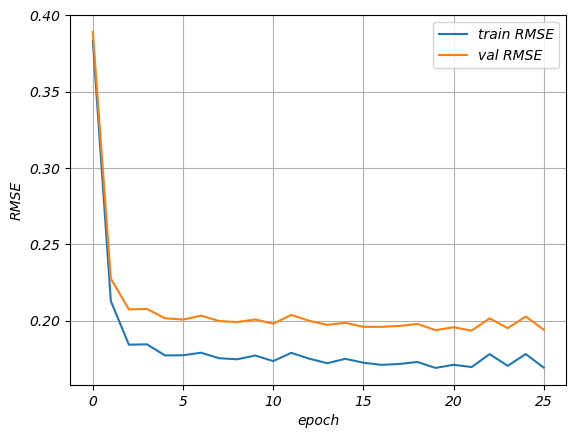

In [17]:
model.eval()
with torch.no_grad():
    test_rmse = (
        torch.mean((model(phi_test)[:, n_burn:] - t_test[:, n_burn:]) ** 2) ** 0.5
    )
    test_nrms = test_rmse / t_test[:, n_burn:].std() * 100

print(f"RMS:  {test_rmse:.6f} rad / {test_rmse / (2 * np.pi) * 360:.6f} deg")
print(f"NRMS: {test_nrms:.4f}%")

# plot learning curve
plt.plot(train_hist, label="train RMSE")
plt.plot(val_hist, label="val RMSE")
plt.xlabel("epoch")
plt.ylabel("RMSE")
plt.legend()
plt.grid()
plt.show()

### 1-step prediction on full dataset

full RMS:  0.1619 rad / 9.2762 deg
full NRMS: 33.77%


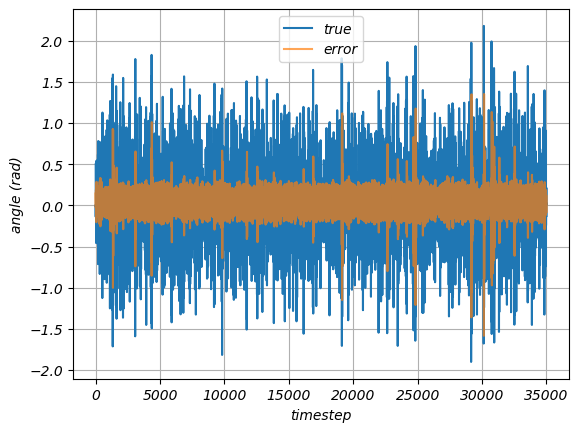

In [18]:
start, length = 1000, 150

x_full = torch.tensor(u_raw, dtype=torch.float32).unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    y_pred_full = model(x_full).cpu().numpy().flatten()

rms = np.mean((y_pred_full[n_burn:] - y_raw[n_burn:]) ** 2) ** 0.5
print(f"full RMS:  {rms:.4f} rad / {rms / (2 * np.pi) * 360:.4f} deg")
print(f"full NRMS: {rms / np.std(y_raw[n_burn:]) * 100:.2f}%")

# plot error against true signal
plt.plot(y_raw, label="true")
plt.plot(y_pred_full - y_raw, label="error", alpha=0.7)
plt.xlabel("timestep")
plt.ylabel("angle (rad)")
plt.legend()
plt.grid()
plt.show()

### segment plot

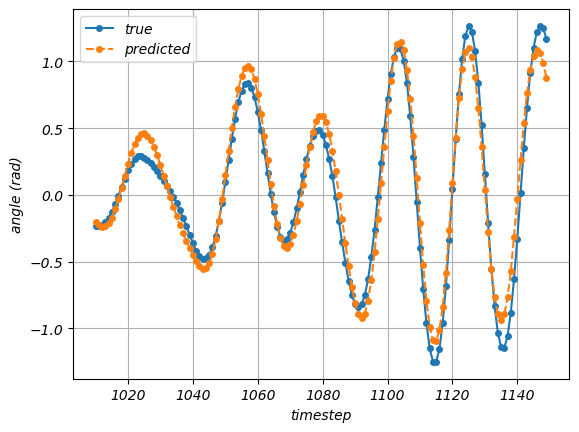

In [19]:
x_seg = (
    torch.tensor(u_raw[start : start + length], dtype=torch.float32)
    .unsqueeze(0)
    .to(device)
)
with torch.no_grad():
    y_pred_seg = model(x_seg).cpu().numpy().flatten()

idx_plot = np.arange(start + n_burn, start + length)

plt.plot(
    idx_plot, y_raw[start + n_burn : start + length], marker="o", ms=4, label="true"
)
plt.plot(idx_plot, y_pred_seg[n_burn:], marker="o", ms=4, ls="--", label="predicted")
plt.xlabel("timestep")
plt.ylabel("angle (rad)")
plt.legend()
plt.grid()
plt.show()